In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import ( 
 col, to_date,  lit, mean as _mean, date_format)
from typing import List, Dict, Tuple
import glob
import gzip
from functools import reduce
import re # Added for the regex file read helper

In [2]:
# --- 1. Spark Session Initialization ---
# This is required to run PySpark.
spark = SparkSession.builder.appName("HostListingAnalysisSpark").getOrCreate()
print(f"Spark Version: {spark.version}")

Spark Version: 4.0.0-preview2


In [3]:
# --- CONFIGURATION (Adapted from availability notebook) ---
COLUMN = "calculated_host_listings_count"
# IMPORTANT: Adjust this to the actual base directory on your cluster/machine.
ROOT_DIR = "" 
# Define the base of the path that is NOT the city-specific key
PATH_PREFIX = "mnt/data/public/insideairbnb/data.insideairbnb.com/"

START_DATE = "2019-01-01"
END_DATE = "2021-12-31"

CITY_CONFIGS = [
    {
        "label": "new-york-city",
        "root_path": f"{PATH_PREFIX}united-states/ny/new-york-city",
        "regex_key": "united-states/ny/new-york-city", 
        "start": "2019-01-09",
        "end": "2021-08-04",
    },
    {
        "label": "austin",
        "root_path": f"{PATH_PREFIX}united-states/tx/austin",
        "regex_key": "united-states/tx/austin",
        "start": "2019-01-14",
        "end": "2021-07-08",
    },
    {
        "label": "los-angeles",
        "root_path": f"{PATH_PREFIX}united-states/ca/los-angeles",
        "regex_key": "united-states/ca/los-angeles",
        "start": "2019-01-11",
        "end": "2021-08-07",
    },
]

In [4]:
def read_file_to_spark_df(spark, filepath: str, target_column: str, date_pattern: str):
    """
    Read a single CSV file using Python (handles gzip issues), 
    then convert to Spark DataFrame for distributed processing.
    Returns None if file can't be read or column doesn't exist.
    """
    # Extract date from filepath
    match = re.search(date_pattern, filepath)
    if not match:
        return None
    file_date = match.group(1)
    
    # Try reading with gzip
    try:
        with gzip.open(filepath, 'rt', encoding='utf-8', errors='ignore') as f:
            pdf = pd.read_csv(f, usecols=[target_column], dtype={target_column: float})
    except:
        # Try as plain CSV
        try:
            pdf = pd.read_csv(filepath, usecols=[target_column], dtype={target_column: float})
        except:
            return None
    
    if target_column not in pdf.columns:
        return None
    
    # Add date column
    pdf["date"] = file_date
    
    # Convert to Spark DataFrame
    return spark.createDataFrame(pdf)

In [5]:
def collect_daily_mean_spark(
    city_configs: List[Dict], column: str, base_dir: str, start_date: str, end_date: str
) -> pd.DataFrame:
    """
    Collects daily means of a column for multiple cities using Spark,
    filtering by a specified date range.
    Returns a Pandas DataFrame containing the daily means (ready for monthly aggregation).
    """
    results = []
    daily_mean_col = f"{column}_mean"
    
    for cfg in city_configs:
        label = cfg["label"]
        root_path = cfg["root_path"]
        regex_key = cfg["regex_key"]
        
        # NOTE: Using recursive glob search to find all files for this city.
        all_files = glob.glob(f"{base_dir}/{root_path}/*/data/listings.csv.gz")
        print(f"[{label}] Files found: {len(all_files)}")
        
        if not all_files:
            print(f"[{label}] No files found.")
            continue
        
        # Regex to extract YYYY-MM-DD date from the path
        date_pattern = rf"{regex_key}/(\d{{4}}-\d{{2}}-\d{{2}})"
        
        # Read all files into Spark DataFrames
        spark_dfs = []
        failed = []
        
        for filepath in all_files:
            sdf = read_file_to_spark_df(spark, filepath, column, date_pattern)
            if sdf is not None:
                # Add the city label here (since the file reader doesn't know it)
                sdf = sdf.withColumn("city_label", lit(label))
                spark_dfs.append(sdf)
            else:
                # Extract date from path for logging purposes
                try:
                    failed.append(filepath.split('/')[-3])
                except IndexError:
                    failed.append("Unknown path structure")
        
        print(f"[{label}] Read: {len(spark_dfs)}, Failed: {len(failed)}")
        if failed:
            print(f"[{label}] Skipped: {failed[:5]}{'...' if len(failed) > 5 else ''}")
        
        if not spark_dfs:
            continue
        
        # Union all Spark DataFrames for this city
        df = reduce(lambda a, b: a.union(b), spark_dfs)
        
        # Convert date string to date type
        df = df.withColumn("date", to_date(col("date"), "yyyy-MM-dd"))
        
        # Date range filter
        df = df.filter(
            (col("date") >= lit(start_date)) & 
            (col("date") <= lit(end_date))
        )
        
        # Filter invalid numeric values (this column should be > 0)
        df = df.filter(col(column).isNotNull())
        if "calculated_host_listings_count" in column:
            df = df.filter(col(column) > 0) # Host must have at least one listing
        
        # Aggregate by date (runs distributed on Spark)
        daily = (
            df.groupBy("date", "city_label")
              .agg(_mean(column).alias(daily_mean_col))
              # Add month column here for later aggregation
              .withColumn("month", date_format(col("date"), "yyyy-MM"))
              .orderBy("date")
        )
        
        # Only convert final aggregated result (daily means) to Pandas
        results.append(daily.toPandas())
    
    if results:
        final_df = pd.concat(results, ignore_index=True)
        return final_df.sort_values(["city_label", "date"]).reset_index(drop=True)
    
    return pd.DataFrame(columns=["city_label", "date", "month", daily_mean_col])

In [6]:
def aggregate_monthly_means_spark(daily_df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Aggregates daily mean data into monthly means using Spark.
    
    This function is required to match the two-step aggregation structure of the
    original Pandas/Multiprocessing notebook (Daily -> Monthly).
    """
    if daily_df.empty:
        return daily_df.copy()

    # Create a Spark DataFrame from the Pandas DataFrame
    spark_df = spark.createDataFrame(daily_df)
    
    daily_mean_col = f"{column}_mean"
    monthly_mean_col = f"{column}_mean_month"

    # Group by city and month, then calculate the mean of the daily means
    month_df_spark = (
        spark_df.groupBy("city_label", "month")
        .agg(_mean(daily_mean_col).alias(monthly_mean_col))
        .sort("city_label", "month")
    )
    
    # Convert the result back to Pandas
    month_df = month_df_spark.toPandas()
    return month_df

In [ ]:
# IMPORTANT: Re-run this entire cell to update the functions!

# Plot multiple cities: monthly average availability
def plot_monthly(city_results: list, column: str, outfile="images/host_monthly_mean.png"):
    plt.figure(figsize=(12, 6))
    IMPORTANT_DATES = [
        "2020-03-11",  # WHO pandemic declaration
        "2021-01-01",
    ]
    for d in IMPORTANT_DATES:
        dt = pd.to_datetime(d)
        plt.axvline(dt, linestyle="--", linewidth=1)
        plt.text(dt, 0, d, rotation=90, va="bottom", fontsize=8)
    
    # Iterate over list of tuples: (label, dataframe)
    for label, data in city_results:
        # Handle both cases: data is a DataFrame or a dict with 'monthly' key
        if isinstance(data, dict):
            month_df = data.get("monthly")
        else:
            month_df = data
        
        if month_df is None or month_df.empty:
            continue
        df = month_df.copy()
        
        # Handle both 'month' and 'date' column names
        date_col = 'month' if 'month' in df.columns else 'date'
        df["month_dt"] = pd.to_datetime(df[date_col])
        col = f"{column}_mean_month"
        plt.plot(df["month_dt"], df[col], marker="o", label=label)
    
    plt.xlabel("Month")
    plt.ylabel("Average Host Listing Count")
    plt.title("Monthly Average calculated_host_listings_count by City")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outfile, dpi=150)
    plt.show()
    print(f"Saved figure to {outfile}")


# Plot multiple cities: yearly average availability
def plot_yearly(city_results: list, column: str, outfile="images/host_yearly_mean.png"):
    """
    Bar chart of yearly average availability (2019, 2020, 2021)
    with numerical labels on each bar.
    """
    all_rows = []
    col_name = f"{column}_mean_month"
    
    # Iterate over list of tuples: (label, dataframe)
    for label, data in city_results:
        # Handle both cases: data is a DataFrame or a dict with 'monthly' key
        if isinstance(data, dict):
            month_df = data.get("monthly")
        else:
            month_df = data
        
        if month_df is None or month_df.empty:
            continue
        df = month_df.copy()
        
        # Handle both 'month' and 'date' column names
        date_col = 'month' if 'month' in df.columns else 'date'
        df["year"] = df[date_col].str.slice(0, 4)
        
        yearly = (
            df.groupby("year")[col_name]
            .mean()
            .reindex(["2019", "2020", "2021"])
        )
        all_rows.append((label, yearly))
    
    # Plot
    plt.figure(figsize=(10, 6))
    years = ["2019", "2020", "2021"]
    x = range(len(years))
    bar_width = 0.25
    offset_index = 0
    
    for label, yearly_series in all_rows:
        y_vals = yearly_series.values
        x_positions = [i + offset_index * bar_width for i in x]
        bars = plt.bar(x_positions, y_vals, width=bar_width, label=label)
        
        for bar, value in zip(bars, y_vals):
            if pd.isna(value):
                continue
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{value:.1f}",
                ha="center",
                va="bottom",
                fontsize=9
            )
        offset_index += 1
    
    plt.xticks([i + bar_width * (len(all_rows) - 1) / 2 for i in x], years)
    plt.ylabel("Avg Host Listings Count")
    plt.title("Yearly Average calculated_host_listings_count (2019–2021)")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(outfile, dpi=150)
    plt.show()
    print(f"Saved bar chart to {outfile}")

In [9]:
# -------------------------------------------------------------
# MAIN EXECUTION BLOCK
# -------------------------------------------------------------
if __name__ == "__main__":
    
    city_results = []
    
    for cfg in CITY_CONFIGS:
        label = cfg['label']
        print(f"\n=== {label} ===")
        
        # --- 1. Spark Processing: DAILY Mean ---
        # This function returns a Pandas DataFrame with the DAILY mean and a 'month' column
        daily_avail_df = collect_daily_mean_spark(
            city_configs=[cfg], # Pass one city config at a time
            column=COLUMN,
            base_dir=ROOT_DIR,
            start_date=START_DATE,
            end_date=END_DATE
        )
        
        if daily_avail_df.empty:
            city_results.append((label, pd.DataFrame()))
            print(f"[{label}] Spark job returned no daily data.")
            continue
            
        # --- 2. Spark Processing: MONTHLY Mean (Aggregating Daily Means) ---
        monthly_avail_df = aggregate_monthly_means_spark(
            daily_df=daily_avail_df,
            column=COLUMN
        )
        
        # NOTE: Drop the city_label column here if plotting functions expect it absent
        # For the original plotting functions, we'll keep the monthly_avail_df as is.

        print(f"\n{label} monthly rows:", len(monthly_avail_df))
        if not monthly_avail_df.empty:
            print(monthly_avail_df.head())
            
        # The result tuples for the plotting functions: (city_label, monthly_data_df)
        city_results.append((label, monthly_avail_df.drop(columns=['city_label'])))
        
    


=== new-york-city ===
[new-york-city] Files found: 83
[new-york-city] Read: 82, Failed: 1
[new-york-city] Skipped: ['2015-01-01']

new-york-city monthly rows: 32
      city_label    month  calculated_host_listings_count_mean_month
0  new-york-city  2019-01                                   4.936905
1  new-york-city  2019-02                                   4.972605
2  new-york-city  2019-03                                   5.742261
3  new-york-city  2019-04                                   6.013828
4  new-york-city  2019-05                                   6.413539

=== austin ===
[austin] Files found: 47
[austin] Read: 47, Failed: 0

austin monthly rows: 30
  city_label    month  calculated_host_listings_count_mean_month
0     austin  2019-01                                   5.448897
1     austin  2019-02                                   5.428226
2     austin  2019-03                                   5.762989
3     austin  2019-04                                   5.909412
4  

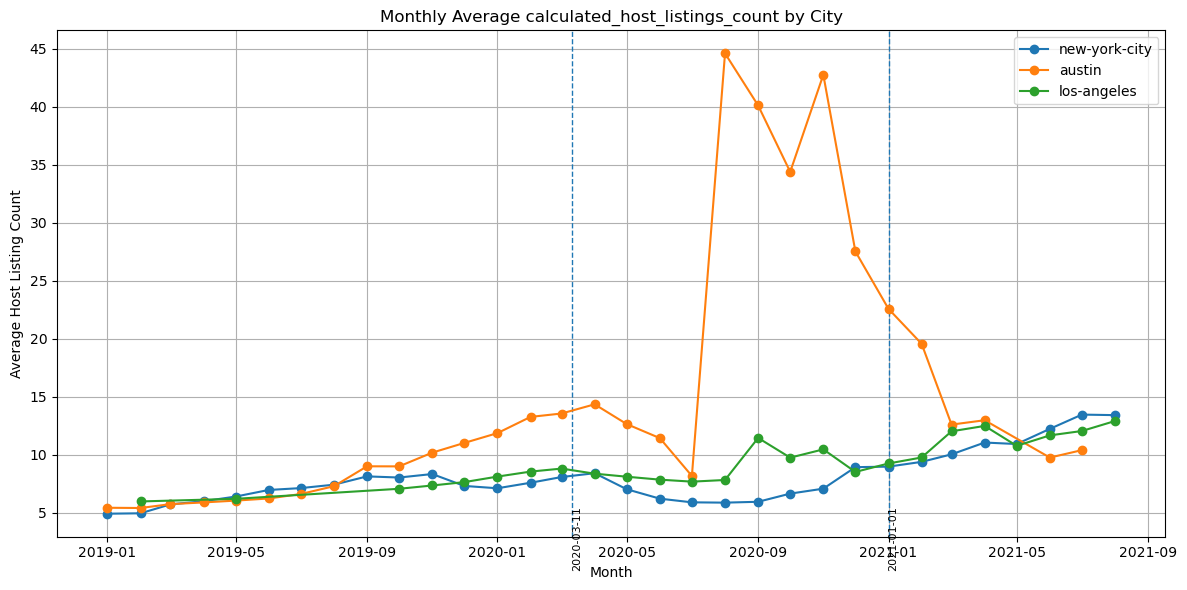

Saved figure to host_monthly_mean.png


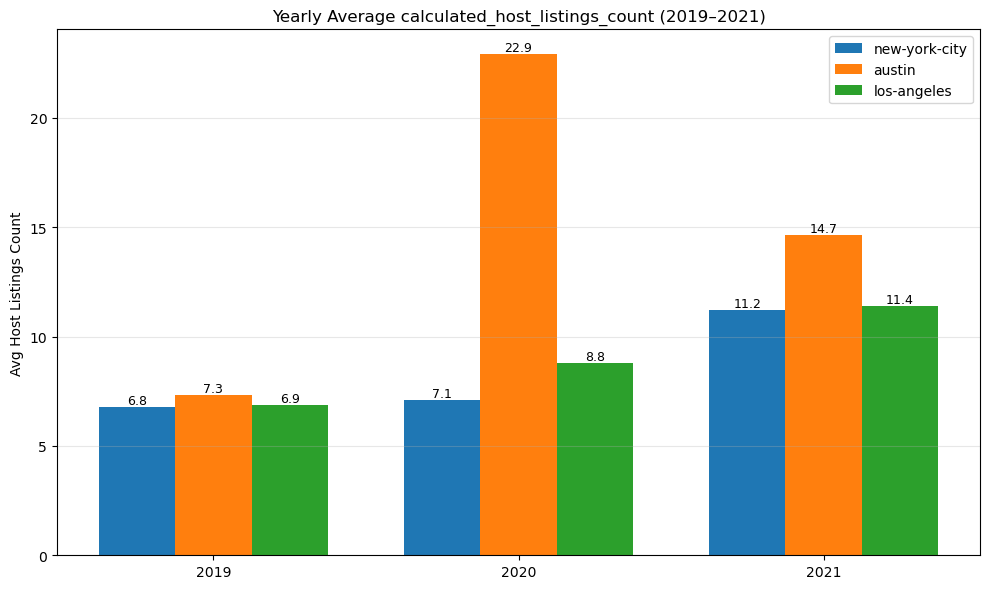

Saved bar chart to host_yearly_mean.png


In [13]:
# --- 3. Plot Comparison ---
if city_results:
    # Pass the monthly data to the plotting functions
    plot_monthly(city_results, COLUMN)
    plot_yearly(city_results, COLUMN)
else:
    print("No data available to plot.")



In [14]:
# Stop the Spark session when done
spark.stop()